In [10]:
import torch
from hydra.utils import instantiate
from omegaconf import OmegaConf
import matplotlib.pyplot as plt

In [22]:
# config_path = "../configs/from_peak_list/singlets_fixed_positions.yaml"
config_path = "../runs/from_peak_list/singlets_fixed_positions-not-wide/config.yaml"

batch_size = 4

config = OmegaConf.load(config_path)
data_config = config.data
data_config.batch_size = batch_size
print(OmegaConf.to_yaml(data_config))
# data_generator = instantiate(data_config)


_target_: shimnet.generators.Generator
input_normalization_height: 16.0
clean_spectra_generator:
  _target_: shimnet.generators.TheoreticalMultipletSpectraGenerator
  pixels: null
  frq_step: ${metadata.frq_step}
  frequency_min: -50
  frequency_max: 650
  peaks_parameter_generator:
    _target_: shimnet.generators.PeaksParametersFromSinglets
    number_of_signals_min: 15
    number_of_signals_max: 45
    use_original_position: true
    position_hz_change_min: -5.0
    position_hz_change_max: 5.0
    use_original_height: false
    height_min: 0.02
    height_max: 10.0
    width_factor_min: 0.8
    width_factor_max: 1.2
    gaussian_fraction_change_min: -0.2
    gaussian_fraction_change_max: 0.2
    singlets_files:
    - data/multiplets_lists/mieszanina_po_reakcji_2-bezszerokich_squeezed-0.0-20.0Hz.csv
response_generator:
  _target_: shimnet.generators.ResponseGenerator
  response_function_library:
    _target_: shimnet.generators.ResponseLibrary
    response_files:
    - data/scrf_81_6

In [23]:
# fix paths (we are in notebooks/ while config paths are relative to project root)
try:
    data_config.clean_spectra_generator.peaks_parameter_generator.singlets_files = ["../" + p for p in data_config.clean_spectra_generator.peaks_parameter_generator.singlets_files]
except AttributeError:
    print("`data_config.clean_spectra_generator.peaks_parameter_generator.singlets_files` not found")
try:
    data_config.response_generator.response_function_library.response_files = ["../" + p for p in data_config.response_generator.response_function_library.response_files]
except AttributeError:
    print("`data_config.response_generator.response_function_library.response_files` not found")
try:
    data_config.clean_spectra_generator.peaks_parameter_generator.multiplets_library.csv_files_paths = ["../" + p for p in data_config.clean_spectra_generator.peaks_parameter_generator.multiplets_library.csv_files_paths]
except AttributeError:
    print("`data_config.clean_spectra_generator.peaks_parameter_generator.multiplets_library.csv_files_paths` not found")



`data_config.clean_spectra_generator.peaks_parameter_generator.multiplets_library.csv_files_paths` not found


## Clean spectra

In [24]:
clean_spectra_generator = instantiate(data_config.clean_spectra_generator)

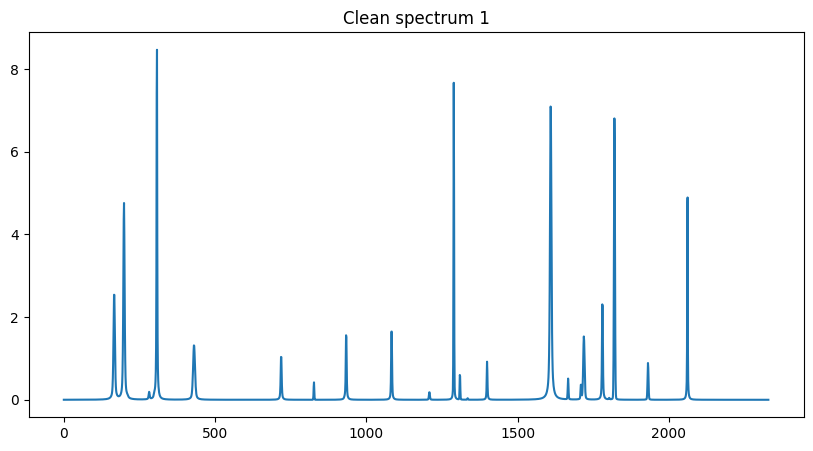

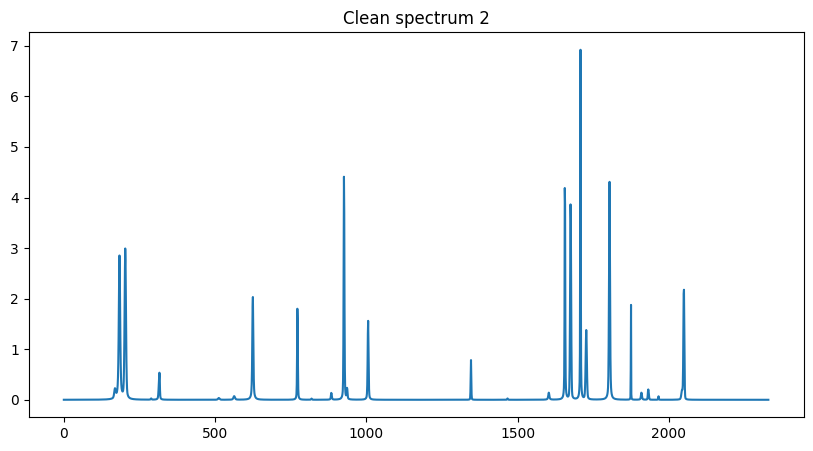

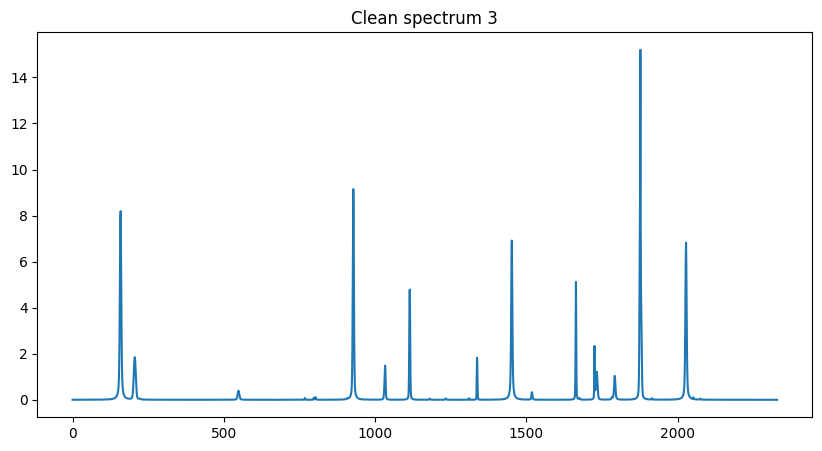

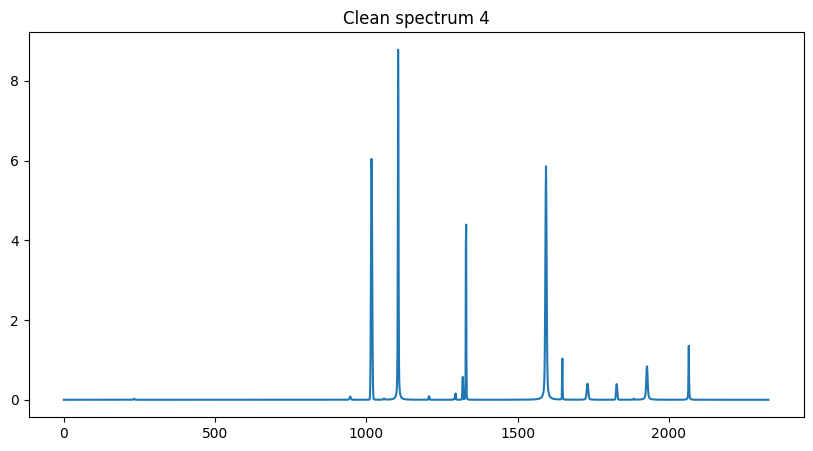

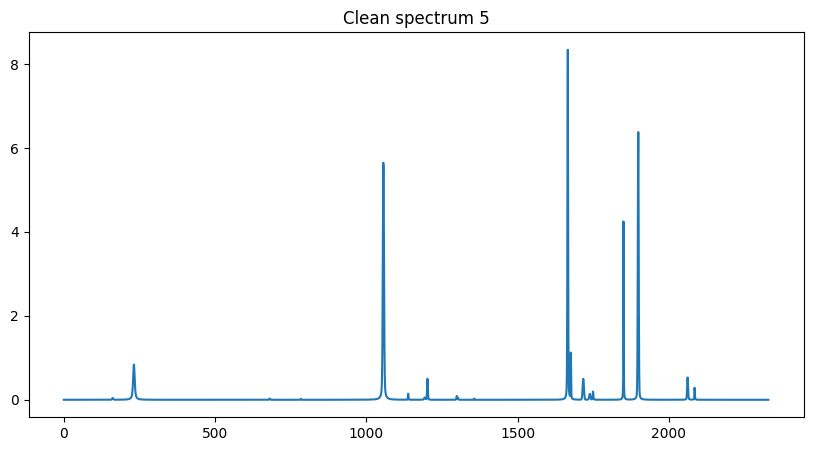

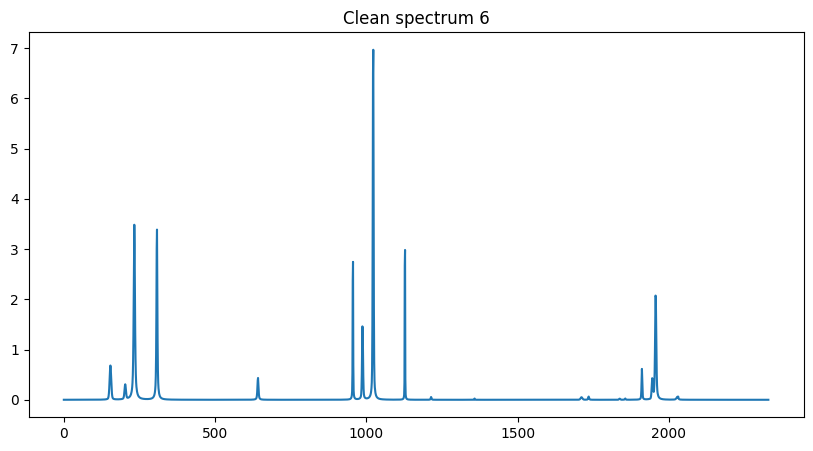

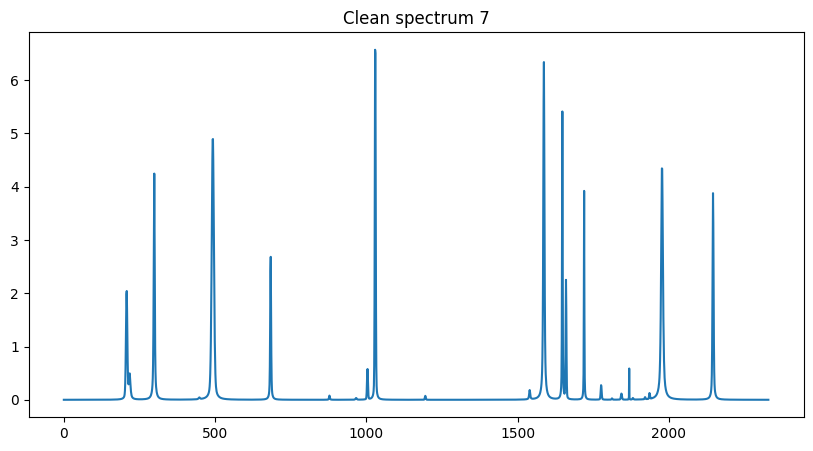

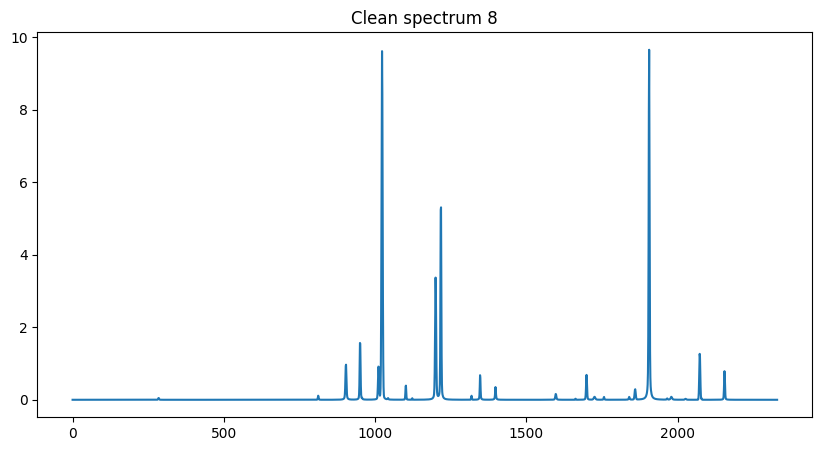

In [25]:
N_samples = 8
for i in range(1, N_samples+1):
    spectrum, spectrum_data = clean_spectra_generator()
    plt.figure(figsize=(10, 5))
    plt.plot(spectrum[0].numpy())
    plt.title(f"Clean spectrum {i}")
    plt.show()

## Full batch

In [ ]:
data_generator = instantiate(data_config)

In [13]:
batch = next(iter(data_generator))
# print(batch.keys())
for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        print(f"{k}: {v.shape}")
    else:
        print(f"{k}: {type(v)}")

disturbed_spectrum: torch.Size([4, 1, 2330])
response_function: torch.Size([4, 1, 1, 81])
theoretical_spectrum: torch.Size([4, 1, 2330])
noised_spectrum: torch.Size([4, 1, 2330])


In [14]:
batch["response_function"].shape

torch.Size([4, 1, 1, 81])

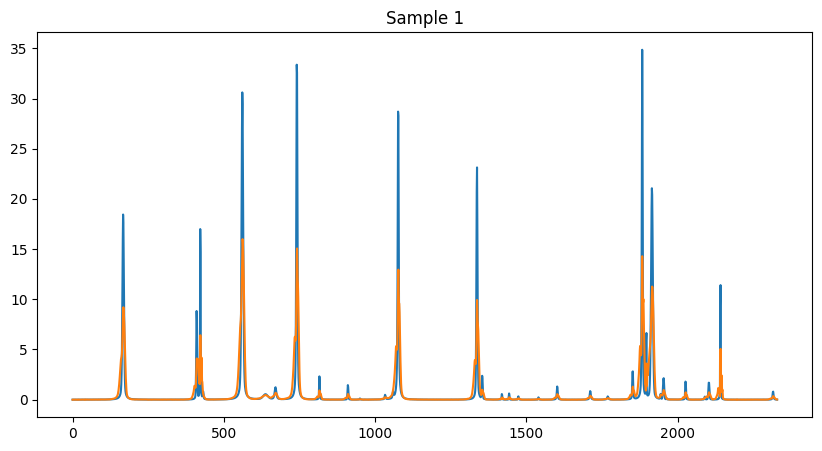

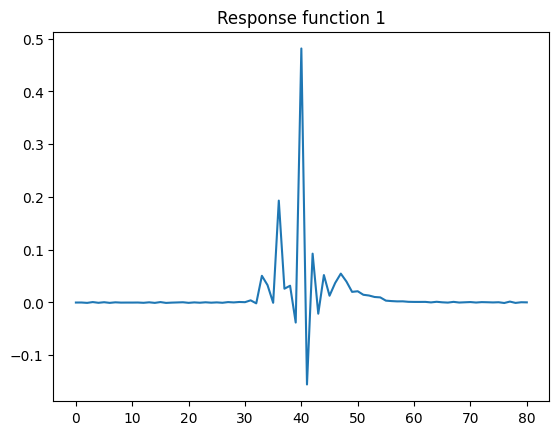

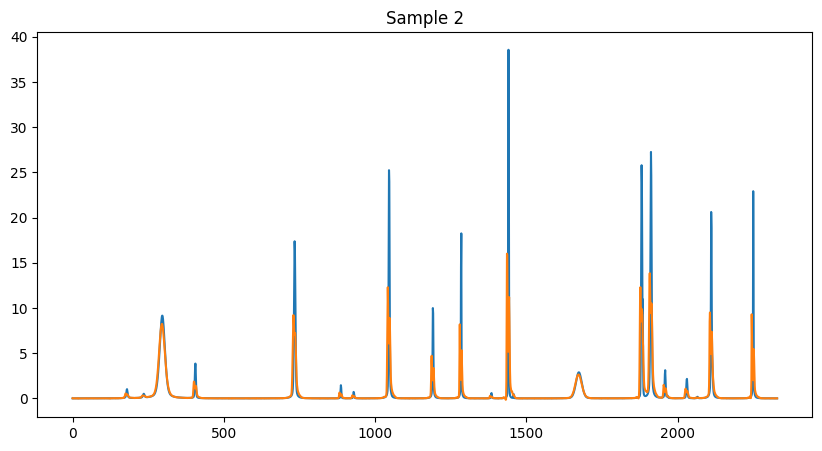

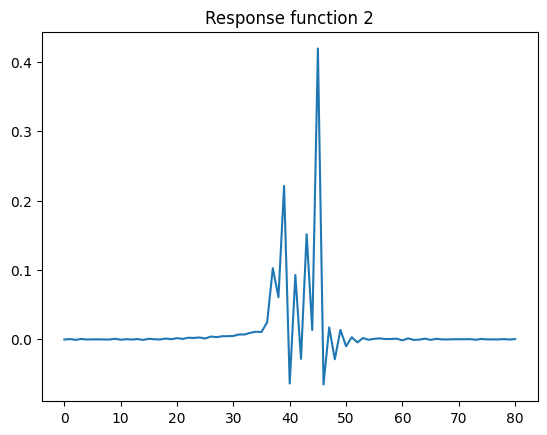

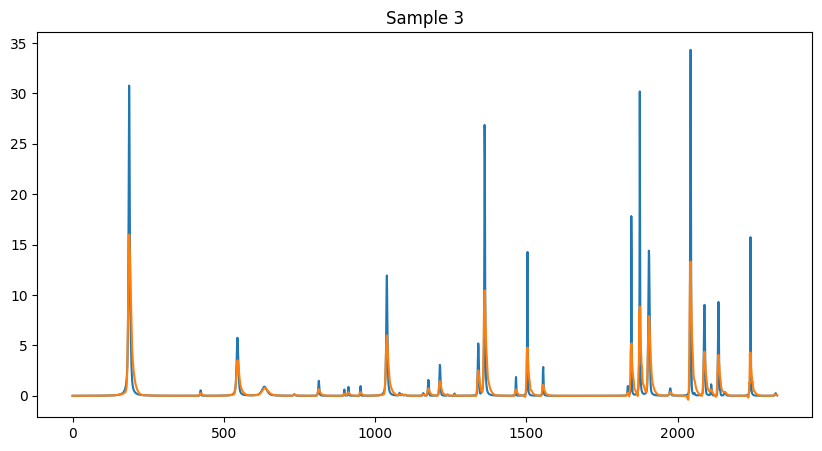

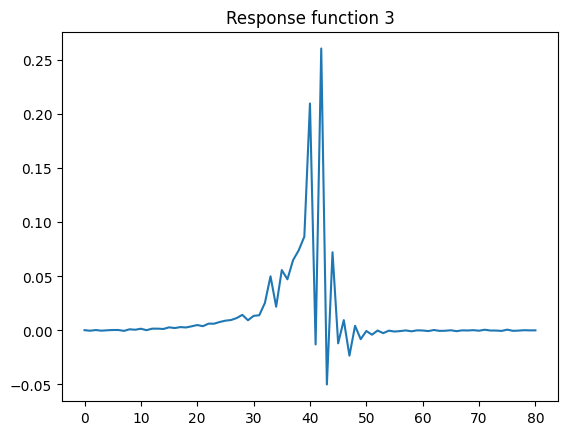

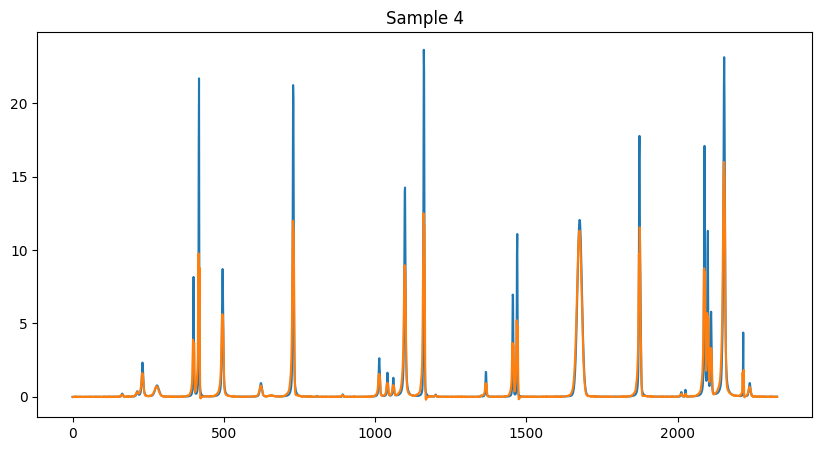

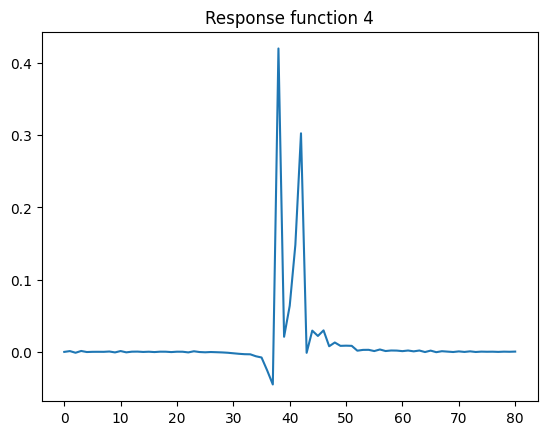

In [15]:
for i, (clean_spectrum, input_spectrum, response) in enumerate(zip(batch["theoretical_spectrum"], batch["noised_spectrum"], batch["response_function"]), start=1):
    plt.figure(figsize=(10, 5))
    plt.plot(clean_spectrum[0].numpy())
    plt.plot(input_spectrum[0].numpy())
    plt.title(f"Sample {i}")
    plt.figure()
    plt.plot(response[0,0].numpy())
    plt.title(f"Response function {i}")
